In [39]:
import os
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["VECLIB_MAXIMUM_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"


CSV_PATH = "../data" 
PLOT_PATH = "../plots"
PARQUET_NON_CONSECUTIVE_PATH = "/data/fs201053/jb88526/"
PARQUET_NON_CONSECUTIVE_THUMBNAIL_PATH = "/data/fs201053/jb88526/tissue_embeddings_full_downscale.parquet"
PARQUET_PREPROCESSING_PATH = "/data/fs201053/jb88526/"
PARQUET_MPP_PATH = "/data/fs201053/jb88526/"
PARQUET_SYNTHETIC_TILES_PATH = "/data/fs201053/jb88526/reidentification_test_complete_v2"
PARQUET_CROSS_SCAN_PATH = "/data/fs201053/jb88526/TODO"

# Loading functions

In [40]:
import os
import re
import urllib.parse
from pathlib import Path
from typing import Tuple, Optional, Union, Dict, List
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import faiss

BAD_MARKERS_REGEX = re.compile(r"PSA|CD34|D240|D2-40|KI67|ER|PR|HER2", re.IGNORECASE)
DIST_REGEX = re.compile(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', re.IGNORECASE)
BAD_POS_REGEX = re.compile(r'(?:VEN|DORS|VENT)\d+-', re.IGNORECASE)
SCANNER_REGEX = re.compile(r'^([A-Z]+).*?(\d{4}_.*?)\.MRXS', re.IGNORECASE)


def _vectorized_parse_and_filter(
    df: pd.DataFrame, 
    filename_col: str, 
    max_section_num: int = 13,
    is_cross_scanner: bool = False
) -> pd.DataFrame:
    """Vectorized parsing and filtering of slide metadata."""
    if df.empty:
        return df

    unique_files = df[filename_col].unique()
    decode_map = {f: urllib.parse.unquote(str(f)).upper() for f in unique_files}
    df['clean_path'] = df[filename_col].map(decode_map)
    df['filename'] = df['clean_path'].str.split('/').str[-1]

    mask = ~df['filename'].str.contains(BAD_MARKERS_REGEX, na=False)
    mask &= ~df['filename'].str.contains(BAD_POS_REGEX, na=False)
    df = df[mask].copy()
    
    if df.empty:
        return df

    if is_cross_scanner:
        scanner_matches = df['filename'].str.extract(SCANNER_REGEX)
        df = df[scanner_matches[0].notna()].copy()
        if df.empty:
            return df
            
        scanner_matches = df['filename'].str.extract(SCANNER_REGEX)
        df['scanner'] = np.where(scanner_matches[0].str.contains("FLASH"), "FLASH", "MIDI")
        
        full_id_with_sections = scanner_matches[1]
        df['patient_id'] = full_id_with_sections.str.rsplit('-', n=1).str[0]
        df['section_num'] = full_id_with_sections.str.extract(r'-(\d{1,2})').astype(float)
    else:
        section_matches = df['filename'].str.extract(DIST_REGEX)
        df = df[section_matches[0].notna()].copy()
        if df.empty:
            return df
            
        df['section_num'] = section_matches[0].astype(float)
        df['patient_id'] = df['clean_path'].str.split('/').str[-2].fillna("unknown")
        df['scanner'] = None

    df = df[df['section_num'] <= max_section_num].copy()
    df['section_num'] = df['section_num'].astype(int)
    
    return df

def load_slide_embeddings(
    parquet_path: Union[str, Path],
    embedding_col: Union[str, List[str]] = "vlad_default",
    filename_col: str = "slide_id",
    max_section_num: int = 13,
    is_cross_scanner: bool = False,
    verbose: bool = True
) -> Union[Tuple[np.ndarray, np.ndarray, np.ndarray, Optional[np.ndarray]], Tuple[np.ndarray, np.ndarray, Dict[str, np.ndarray]]]:
    
    is_multi = isinstance(embedding_col, list)
    cols_to_load = embedding_col if is_multi else [embedding_col]
    
    try:
        meta_table = pq.read_table(parquet_path, columns=[filename_col])
        meta_df = meta_table.to_pandas()
        orig_rows = len(meta_df)
        meta_df['orig_idx'] = np.arange(orig_rows)
        
        filtered_df = _vectorized_parse_and_filter(
            meta_df, 
            filename_col=filename_col, 
            max_section_num=max_section_num, 
            is_cross_scanner=is_cross_scanner
        )
        
        if filtered_df.empty:
            if is_multi: return None
            return np.array([]), np.array([]), np.empty((0, 0), dtype='float32'), None
            
        valid_indices = filtered_df['orig_idx'].values
        patient_ids = filtered_df['patient_id'].values
        slice_nums = filtered_df['section_num'].values
        scanners = filtered_df['scanner'].values if is_cross_scanner else None
        
        full_table = pq.read_table(parquet_path, columns=cols_to_load)
        
        if is_multi:
            data_per_col = {}
            for col in cols_to_load:
                filtered_embeddings_list = full_table.column(col).take(valid_indices).to_pylist()
                embeddings = np.stack(filtered_embeddings_list).astype('float32')
                faiss.normalize_L2(embeddings)
                data_per_col[col] = embeddings
            return patient_ids, slice_nums, data_per_col
        else:
            single_col = cols_to_load[0]
            filtered_embeddings_list = full_table.column(single_col).take(valid_indices).to_pylist()
            embeddings = np.stack(filtered_embeddings_list).astype('float32')
            faiss.normalize_L2(embeddings)
            
            if verbose:
                print(f"Loaded: {Path(parquet_path).name} | Rows: {orig_rows} -> {len(filtered_df)}")
            return patient_ids, slice_nums, embeddings, scanners
            
    except Exception as e:
        if is_multi: return None
        raise e

# Attack functions

In [41]:
import numpy as np
import faiss

def calculate_rs_pure_python(patient_ids: np.ndarray, embeddings: np.ndarray) -> float:
    """Calculate re-identification risk (Rs) - pure Python implementation."""
    n, dim = embeddings.shape
    if n < 2: 
        return 0.0
    
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    
    _, indices = index.search(embeddings, 2)
    
    predicted_ids = patient_ids[indices[:, 1]]
    
    correct_mask = (patient_ids == predicted_ids)
    
    vulnerable_patients = set(patient_ids[correct_mask])
    total_patients = len(set(patient_ids))
    
    return len(vulnerable_patients) / total_patients if total_patients > 0 else 0.0


def calculate_rs_by_distance(
    patient_ids: np.ndarray, 
    slice_nums: np.ndarray, 
    embeddings: np.ndarray, 
    max_dist: int = 10
) -> Dict[int, float]:
    """Calculate distance-based re-identification risk."""
    n, dim = embeddings.shape
    if n < 2: 
        return {d: 0.0 for d in range(1, max_dist + 1)}
    
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    
    k = min(50, n)
    _, indices = index.search(embeddings, k)
    
    neighbor_pids = patient_ids[indices]
    neighbor_slices = slice_nums[indices]
    
    rs_results = {}
    unique_pids = set(patient_ids)
    total_patients = len(unique_pids)
    
    vulnerable_by_dist = {d: set() for d in range(1, max_dist + 1)}
    
    for i in range(n):
        current_pid = patient_ids[i]
        current_slice = slice_nums[i]
        
        pids_i = neighbor_pids[i, 1:]
        slices_i = neighbor_slices[i, 1:]
        
        first_diff_idx = np.where(pids_i != current_pid)[0]
        cutoff = first_diff_idx[0] if len(first_diff_idx) > 0 else len(pids_i)
        
        if cutoff > 0:
            valid_slices = slices_i[:cutoff]
            abs_distances = np.abs(valid_slices - current_slice)
            
            for d in range(1, max_dist + 1):
                if np.any(abs_distances == d):
                    vulnerable_by_dist[d].add(current_pid)
                    
    for d in range(1, max_dist + 1):
        rs_results[d] = len(vulnerable_by_dist[d]) / total_patients if total_patients > 0 else 0.0
        
    return rs_results

# NONCONSECUTIVE SLIDES TILES

In [46]:
import gc
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import faiss

def _process_single_method_distance(col, loaded_results, patient_ids, slice_nums, max_dist):
    all_embs = []
    for _, _, col_data in loaded_results:
        if col in col_data:
            all_embs.append(col_data[col])
            
    if not all_embs:
        return None
        
    embeddings = np.vstack(all_embs).astype('float32')
    faiss.normalize_L2(embeddings)
    
    rs_dist_map = calculate_rs_by_distance(patient_ids, slice_nums, embeddings, max_dist)
    return col, rs_dist_map

def run_full_distance_analysis(base_path, encoders, methods, max_dist=10):
    all_results = []

    for e_key in encoders:
        main_path = Path(base_path) / f"privagams_enc{e_key}_mpp10_enhanced_slides_v5"
        if not main_path.exists():
            print(f"Directory not found: {main_path}")
            continue
            
        print(f"\n>>> Processing Encoder: {e_key}")
        seed_folders = sorted([d for d in main_path.iterdir() if "run_seed_" in d.name])
        
        for sf in tqdm(seed_folders, desc="Seeds Progress"):
            seed_val = sf.name.split("_")[-1]
            p_files = list(sf.glob("*.parquet"))
            if not p_files: 
                continue

            with ThreadPoolExecutor(max_workers=8) as executor:
                loaded_results = list(executor.map(
                    lambda pf: load_slide_embeddings(
                        parquet_path=pf, 
                        embedding_col=methods,
                        filename_col="slide_id",
                        max_section_num=13,
                        is_cross_scanner=False,
                        verbose=False
                    ), 
                    p_files
                ))
            
            loaded_results = [r for r in loaded_results if r is not None]
            if not loaded_results:
                continue
                
            all_pids = [r[0] for r in loaded_results if len(r[0]) > 0]
            all_slices = [r[1] for r in loaded_results if len(r[1]) > 0]
            
            if not all_pids:
                continue
                
            patient_ids = np.concatenate(all_pids)
            slice_nums = np.concatenate(all_slices)
            
            with ThreadPoolExecutor(max_workers=4) as executor:
                distance_tasks = list(executor.map(
                    lambda col: _process_single_method_distance(
                        col, loaded_results, patient_ids, slice_nums, max_dist
                    ),
                    methods
                ))
                
            for task_res in distance_tasks:
                if task_res is None:
                    continue
                col, rs_dist_map = task_res
                for d, val in rs_dist_map.items():
                    all_results.append({
                        "encoder": e_key,
                        "method": col,
                        "seed": seed_val,
                        "distance": d,
                        "rs_value": val
                    })
                    
            del loaded_results, patient_ids, slice_nums
            gc.collect()

    return pd.DataFrame(all_results)

In [47]:
ENCODERS = ["0", "1", "2", "3", "4"]
METHODS = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
    "mean_default",
    "mean_default_super",
]

if os.path.exists(CSV_PATH+"/rs_distance_analysis.csv"):
    df_final_dist = pd.read_csv(CSV_PATH+"/rs_distance_analysis.csv")
else:
    df_final_dist = run_full_distance_analysis(PARQUET_NON_CONSECUTIVE_PATH, ENCODERS, METHODS, max_dist=10)
    os.makedirs(os.path.dirname(CSV_PATH + "/rs_distance_analysis.csv"), exist_ok=True)
    df_final_dist.to_csv(CSV_PATH + "/rs_distance_analysis.csv", index=False)


>>> Processing Encoder: 0


Seeds Progress: 100%|██████████| 20/20 [02:15<00:00,  6.80s/it]



>>> Processing Encoder: 1


Seeds Progress: 100%|██████████| 20/20 [02:17<00:00,  6.89s/it]



>>> Processing Encoder: 2


Seeds Progress: 100%|██████████| 20/20 [02:21<00:00,  7.05s/it]



>>> Processing Encoder: 3


Seeds Progress: 100%|██████████| 20/20 [02:17<00:00,  6.86s/it]



>>> Processing Encoder: 4


Seeds Progress: 100%|██████████| 20/20 [02:17<00:00,  6.89s/it]


In [48]:
from collections import defaultdict

def get_probe_statistics_standalone(base_path, max_dist=10):
    """Calculate probe statistics per patient at different distances."""
    main_path = Path(base_path)
    parquet_files = list(main_path.glob("**/*.parquet"))
    print(f"Found {len(parquet_files)} files. Parsing metadata via vectorized loader...")

    patient_slices = defaultdict(set)
    
    for pf in parquet_files:
        p_ids, s_nums, _, _ = load_slide_embeddings(
            parquet_path=pf,
            embedding_col="vlad_default",
            filename_col="__filename",
            max_section_num=13,
            is_cross_scanner=False,
            verbose=False
        )
        
        for pid, s_num in zip(p_ids, s_nums):
            patient_slices[pid].add(s_num)
            
    total_patients = len(patient_slices)
    results = []

    for d in range(1, max_dist + 1):
        total_probes_at_dist = 0
        
        for pid, slices in patient_slices.items():
            probes_for_this_patient = 0
            for s in slices:
                if (s + d) in slices or (s - d) in slices:
                    probes_for_this_patient += 1
            total_probes_at_dist += probes_for_this_patient
        
        avg_probes = total_probes_at_dist / total_patients if total_patients > 0 else 0
        results.append({
            "Distance": d,
            "Total Probes": total_probes_at_dist,
            "Probes per Patient": round(avg_probes, 2)
        })

    return pd.DataFrame(results)

In [49]:
if os.path.exists(CSV_PATH+"/probe_statistics.csv"):
    print(f"Loading cached stats from {CSV_PATH+'/probe_statistics.csv'}")
    stats_df = pd.read_csv(CSV_PATH+"/probe_statistics.csv")
else:
    stats_df = get_probe_statistics_standalone(PARQUET_NON_CONSECUTIVE_PATH + "/privagams_enc0_mpp10_enhanced_slides_v5/" + os.listdir(PARQUET_NON_CONSECUTIVE_PATH+"/privagams_enc0_mpp10_enhanced_slides_v5")[0], max_dist=10)
    os.makedirs(os.path.dirname(CSV_PATH + "/probe_statistics.csv"), exist_ok=True)
    stats_df.to_csv(CSV_PATH + "/probe_statistics.csv", index=False)

probe_stats = dict(zip(stats_df["Distance"], stats_df["Probes per Patient"].round(1)))

print("\n--- PROBE STATISTICS PER PATIENT (CLEANED DATA) ---")
print(probe_stats)

Found 560 files. Parsing metadata via vectorized loader...

--- PROBE STATISTICS PER PATIENT (CLEANED DATA) ---
{1: 6.7, 2: 6.7, 3: 6.5, 4: 5.3, 5: 3.8, 6: 2.2, 7: 1.2, 8: 0.6, 9: 0.2, 10: 0.1}


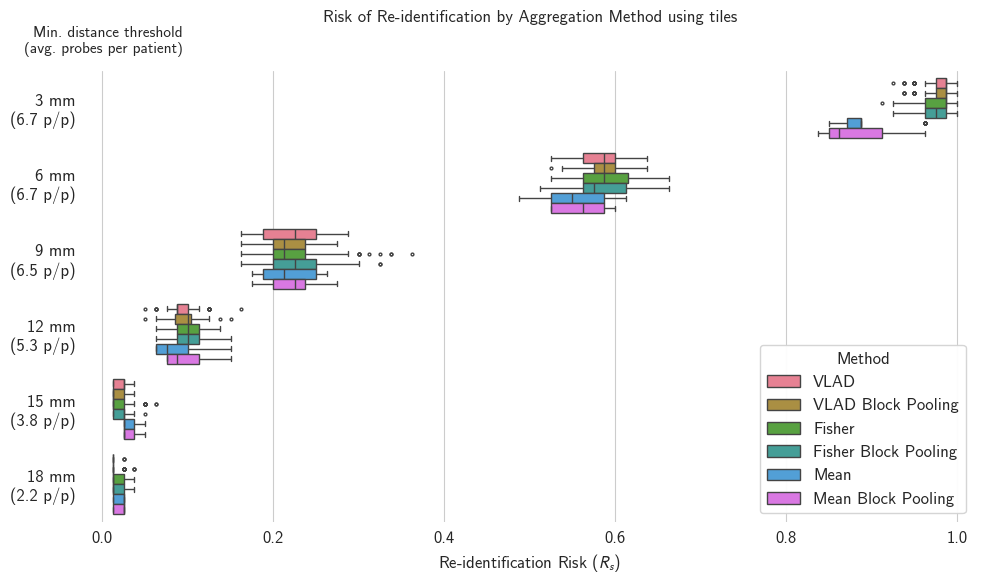

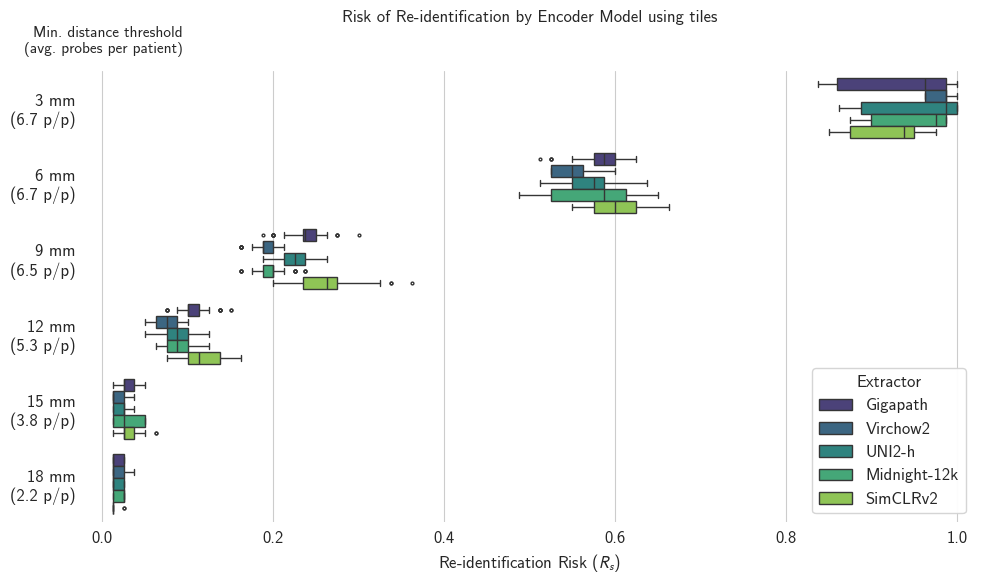

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Computer Modern Sans Serif",
            "cmss10",
            "Helvetica",
            "Arial",
        ],
        "mathtext.fontset": "stixsans",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

MM_PER_SLICE = 3
MAX_DISTANCE = 6  

method_rename = {
    'vlad_default': 'VLAD',
    'vlad_default_super': 'VLAD Block Pooling',
    'fisher_default': 'Fisher',
    'fisher_default_super': 'Fisher Block Pooling',
    'mean_default': 'Mean',
    'mean_default_super': 'Mean Block Pooling',
}

df_plot = df_final_dist.copy()
df_plot = df_plot[df_plot['distance'] <= MAX_DISTANCE]
df_plot['encoder'] = df_plot['encoder'].astype(str)

encoder_rename_str = {
    '0': 'Gigapath', '1': 'Virchow2', '2': 'UNI2-h', '3': 'Midnight-12k', '4': 'SimCLRv2'
}

df_plot['method'] = df_plot['method'].map(method_rename).fillna(df_plot['method'])
df_plot['encoder'] = df_plot['encoder'].map(encoder_rename_str).fillna(df_plot['encoder'])

def create_label(dist):
    mm = dist * MM_PER_SLICE
    pp = probe_stats.get(dist, 0)
    return f"{mm:g} mm\n({pp} p/p)"

df_plot['threshold_label'] = df_plot['distance'].apply(create_label)
dist_order = [create_label(d) for d in range(1, MAX_DISTANCE + 1)]

def finalize_plot(ax, title, legend_title):
    ax.set_title(title, pad=35, fontweight='bold')
    ax.set_xlabel("Re-identification Risk ($R_s$)")
    
    ax.set_ylabel("")
    
    ax.text(
        x=0.11, 
        y=1.03, 
        s="Min. distance threshold\n(avg. probes per patient)",
        transform=ax.transAxes,
        rotation=0,
        horizontalalignment='right',
        verticalalignment='bottom',
        fontsize=11
    )
    
    plt.setp(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
    
    ax.legend(title=legend_title, loc='lower right', frameon=True, framealpha=0.95, edgecolor='#d3d3d3')
    
    ax.set_xlim(-0.02, 1.02)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.savefig(PLOT_PATH + f"/rs_distance_analysis_{title.replace(' ', '_').lower()}.png", format='png', bbox_inches='tight')

plt.figure(figsize=(10, 6))
ax1 = sns.boxplot(
    data=df_plot, x="rs_value", y="threshold_label", hue="method",
    order=dist_order, orient="h", palette="husl", fliersize=2
)
finalize_plot(ax1, "Risk of Re-identification by Aggregation Method using tiles", "Method")

plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(
    data=df_plot, x="rs_value", y="threshold_label", hue="encoder",
    order=dist_order, orient="h", palette="viridis", fliersize=2
)
finalize_plot(ax2, "Risk of Re-identification by Encoder Model using tiles", "Extractor")

plt.show()

# THUMBNAIL ANALYSIS

In [51]:
def run_thumbnail_analysis(input_dir, models, max_dist=10):
    """Run analysis on thumbnail embeddings."""
    input_path = Path(input_dir)
    p_files = list(input_path.glob("*.parquet")) if input_path.is_dir() else [input_path]
    
    if not p_files:
        print("No Parquet files found.")
        return pd.DataFrame()

    all_results = []
    
    patient_ids = None
    slice_nums = None
    metadata_initialized = False

    for m in models:
        print(f"\n>>> Computing Rs for model: {m}")
        target_embedding_col = f"emb_{m}"
        all_embs = []
        
        all_pids, all_slices = [], []

        for pf in p_files:
            p_ids, s_nums, embs, _ = load_slide_embeddings(
                parquet_path=pf,
                embedding_col=target_embedding_col,
                filename_col="slide_id",
                max_section_num=13,
                is_cross_scanner=False,
                verbose=False
            )
            
            if len(p_ids) > 0:
                all_embs.append(embs)
                if not metadata_initialized:
                    all_pids.append(p_ids)
                    all_slices.append(s_nums)

        if not all_embs:
            print(f"Skipping model {m} - no valid embeddings could be extracted.")
            continue

        embeddings = np.vstack(all_embs).astype('float32')
        
        if not metadata_initialized:
            patient_ids = np.concatenate(all_pids)
            slice_nums = np.concatenate(all_slices)
            metadata_initialized = True

        faiss.normalize_L2(embeddings)
        
        rs_dist_map = calculate_rs_by_distance(patient_ids, slice_nums, embeddings, max_dist)
        
        for d, val in rs_dist_map.items():
            all_results.append({
                "model": m,
                "distance": d,
                "rs_value": val
            })
            
        del embeddings
        gc.collect()

    return pd.DataFrame(all_results)

In [52]:
MAX_DIST = 13
MODELS = ["gigapath", "virchow2", "uni2h", "midnight", "simclrv2"]

if os.path.exists(CSV_PATH+"/rs_distance_analysis_thumbnail.csv"):
    df_final = pd.read_csv(CSV_PATH+"/rs_distance_analysis_thumbnail.csv")
else:
    df_final = run_thumbnail_analysis(PARQUET_NON_CONSECUTIVE_THUMBNAIL_PATH, MODELS, max_dist=MAX_DIST)
    os.makedirs(os.path.dirname(CSV_PATH + "/rs_distance_analysis_thumbnail.csv"), exist_ok=True)
    df_final.to_csv(CSV_PATH + "/rs_distance_analysis_thumbnail.csv", index=False)


>>> Computing Rs for model: gigapath

>>> Computing Rs for model: virchow2

>>> Computing Rs for model: uni2h

>>> Computing Rs for model: midnight

>>> Computing Rs for model: simclrv2


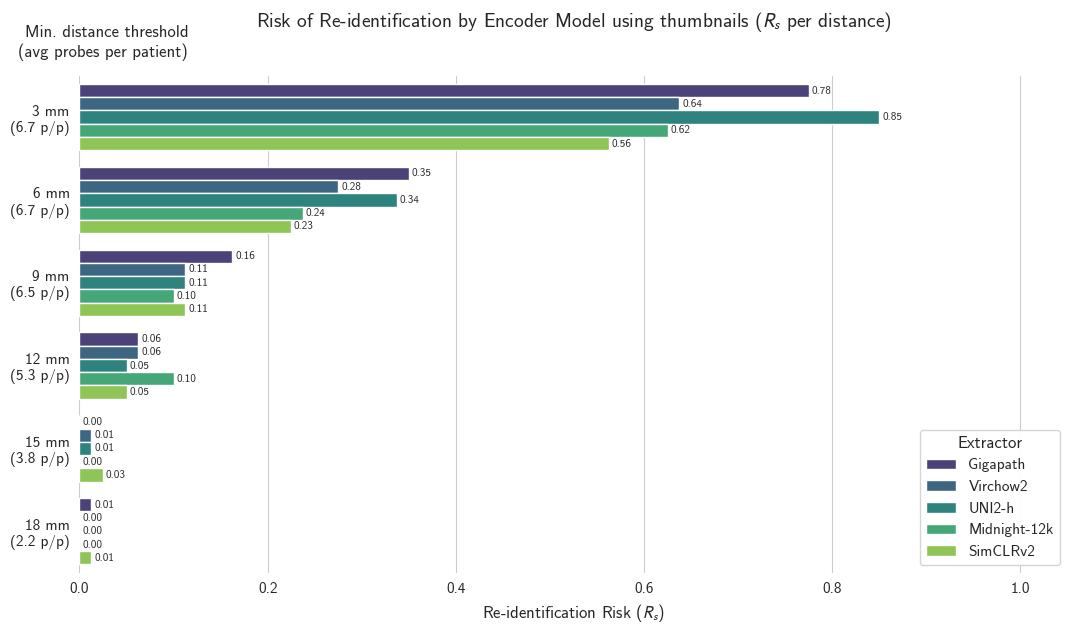

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Computer Modern Sans Serif",
            "cmss10",
            "Helvetica",
            "Arial",
        ],
        "mathtext.fontset": "stixsans",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

MM_PER_SLICE = 3
MAX_DISTANCE = 6

encoder_rename_str = {
    "gigapath": "Gigapath",
    "virchow2": "Virchow2",
    "uni2h": "UNI2-h",
    "midnight": "Midnight-12k",
    "simclrv2": "SimCLRv2",
}

probe_stats_thumb = probe_stats

df_plot = df_final.copy()
df_plot["distance"] = df_plot["distance"].astype(int)
df_plot = df_plot[df_plot["distance"] <= MAX_DISTANCE]

df_plot["model"] = (
    df_plot["model"].astype(str).map(encoder_rename_str).fillna(df_plot["model"])
)

def create_label(dist):
    mm = dist * MM_PER_SLICE
    pp = probe_stats_thumb.get(dist, 0)
    return f"{mm:g} mm\n({pp} p/p)"


df_plot["threshold_label"] = df_plot["distance"].apply(create_label)
dist_order = [create_label(d) for d in range(1, MAX_DISTANCE + 1)]

plt.figure(figsize=(11, 6.5))

ax = sns.barplot(
    data=df_plot,
    x="rs_value",
    y="threshold_label",
    hue="model",
    order=dist_order,
    orient="h",
    palette="viridis",
)

ax.set_title(
    "Risk of Re-identification by Encoder Model using thumbnails ($R_s$ per distance)",
    pad=35,
    fontweight="bold",
)
ax.set_xlabel("Re-identification Risk ($R_s$)")

ax.set_ylabel("")

ax.text(
    x=0.11,
    y=1.03,
    s="Min. distance threshold\n(avg probes per patient)",
    transform=ax.transAxes,
    rotation=0,
    horizontalalignment="right",
    verticalalignment="bottom",
)

plt.setp(ax.get_yticklabels(), rotation=0, horizontalalignment="right")

ax.legend(
    title="Extractor",
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    edgecolor="#d3d3d3",
)

plt.xlim(0, 1.05)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2,
        fontsize=8,
    )

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig(PLOT_PATH + "/rs_distance_analysis_of_re-identification_thumbnails.png", dpi=300)
plt.show()

# PREPROCESSING CHECK

In [56]:
import gc
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import faiss

def analyze_experiments_fast(base_path, encoders, param_values, aggregation_methods, experiment_type="preprocessing"):
    results_data = []
    enc_map = {"1": "Virchow2", "2": "UNI2-h"}
    agg_map = {
        'mean_default': 'Mean', 'mean_default_super': 'Mean Block Pooling',
        'vlad_default': 'VLAD', 'vlad_default_super': 'VLAD Block Pooling',
        'fisher_default': 'Fisher', 'fisher_default_super': 'Fisher Block Pooling'
    }

    if experiment_type == "preprocessing":
        folder_suffix = "pre_check"
        param_column_name = "preprocessing"
    elif experiment_type == "mpp":
        folder_suffix = "mpp_check"
        param_column_name = "mpp"
    else:
        raise ValueError("experiment_type must be 'preprocessing' or 'mpp'")

    for e_key in encoders:
        for val in param_values:
            if experiment_type == "preprocessing":
                folder_name = f"privagams_enc{e_key}_mpp10_{val}_{folder_suffix}"
            else:
                folder_name = f"privagams_enc{e_key}_mpp{val}_enhanced_{folder_suffix}"
                
            main_path = Path(base_path) / folder_name
            if not main_path.exists(): 
                continue
            
            encoder_name = enc_map.get(e_key, e_key)
            seed_folders = sorted([d for d in main_path.iterdir() if "run_seed_" in d.name])
            
            for sf in tqdm(seed_folders, desc=f"Processing {encoder_name} ({val})"):
                seed_val = sf.name.split("_")[-1]
                p_files = list(sf.glob("*.parquet"))
                if not p_files: 
                    continue

                with ThreadPoolExecutor(max_workers=8) as executor:
                    loaded_results = list(executor.map(
                        lambda pf: load_slide_embeddings(
                            parquet_path=pf, 
                            embedding_col=aggregation_methods,
                            filename_col="slide_id",
                            max_section_num=13,
                            is_cross_scanner=False,
                            verbose=False
                        ), 
                        p_files
                    ))
                
                loaded_results = [r for r in loaded_results if r is not None]
                if not loaded_results:
                    continue
                    
                for agg_col in aggregation_methods:
                    all_pids = []
                    all_embs = []
                    
                    # FIXED LINE: Added _ to cleanly catch and ignore slice_nums
                    for pids, _, col_data in loaded_results:
                        if agg_col in col_data and len(pids) > 0:
                            all_pids.append(pids)
                            all_embs.append(col_data[agg_col])
                            
                    if not all_embs: 
                        continue
                        
                    patient_ids = np.concatenate(all_pids)
                    embeddings = np.vstack(all_embs).astype('float32')
                    
                    faiss.normalize_L2(embeddings)
                    rs_val = calculate_rs_pure_python(patient_ids, embeddings)
                    
                    results_data.append({
                        "encoder": encoder_name,
                        param_column_name: val,
                        "aggregator": agg_map.get(agg_col, agg_col),
                        "rs_value": rs_val,
                        "seed": seed_val
                    })
                    
                del loaded_results
                gc.collect()
                        
    return pd.DataFrame(results_data)

## Preprocessing

In [57]:
ENC = ["1", "2"]
PREPROCESSING_VALS = ["rmbg", "rmbg_norm", "rmbg_clahe", "enhanced"]
AGGREGATORS = ["mean_default", "mean_default_super", "vlad_default", "vlad_default_super", "fisher_default", "fisher_default_super"]

if os.path.exists(CSV_PATH+"/preprocessing_analysis.csv"):
    df_preprocessing = pd.read_csv(CSV_PATH+"/preprocessing_analysis.csv")
else:
    df_preprocessing = analyze_experiments_fast(PARQUET_PREPROCESSING_PATH, ENC, PREPROCESSING_VALS, AGGREGATORS, experiment_type="preprocessing")
    df_preprocessing.to_csv(CSV_PATH+"/preprocessing_analysis.csv", index=False)

Processing UNI2-h (enhanced): 100%|██████████| 20/20 [02:19<00:00,  6.98s/it]


## MPP

In [58]:
PATH = "/data/fs201053/jb88526/"
ENC = ["1", "2"]
AGGREGATORS = ["mean_default", "mean_default_super", "vlad_default", "vlad_default_super", "fisher_default", "fisher_default_super"]
MPP_VALS = ["05", "10", "20"]

if os.path.exists(CSV_PATH+"/mpp_analysis.csv"):
    df_mpp = pd.read_csv(CSV_PATH+"/mpp_analysis.csv")
else:
    df_mpp = analyze_experiments_fast(PARQUET_MPP_PATH, ENC, MPP_VALS, AGGREGATORS, experiment_type="mpp")
    df_mpp.to_csv(CSV_PATH+"/mpp_analysis.csv", index=False)

Processing UNI2-h (20): 100%|██████████| 20/20 [02:20<00:00,  7.01s/it]


## Plots

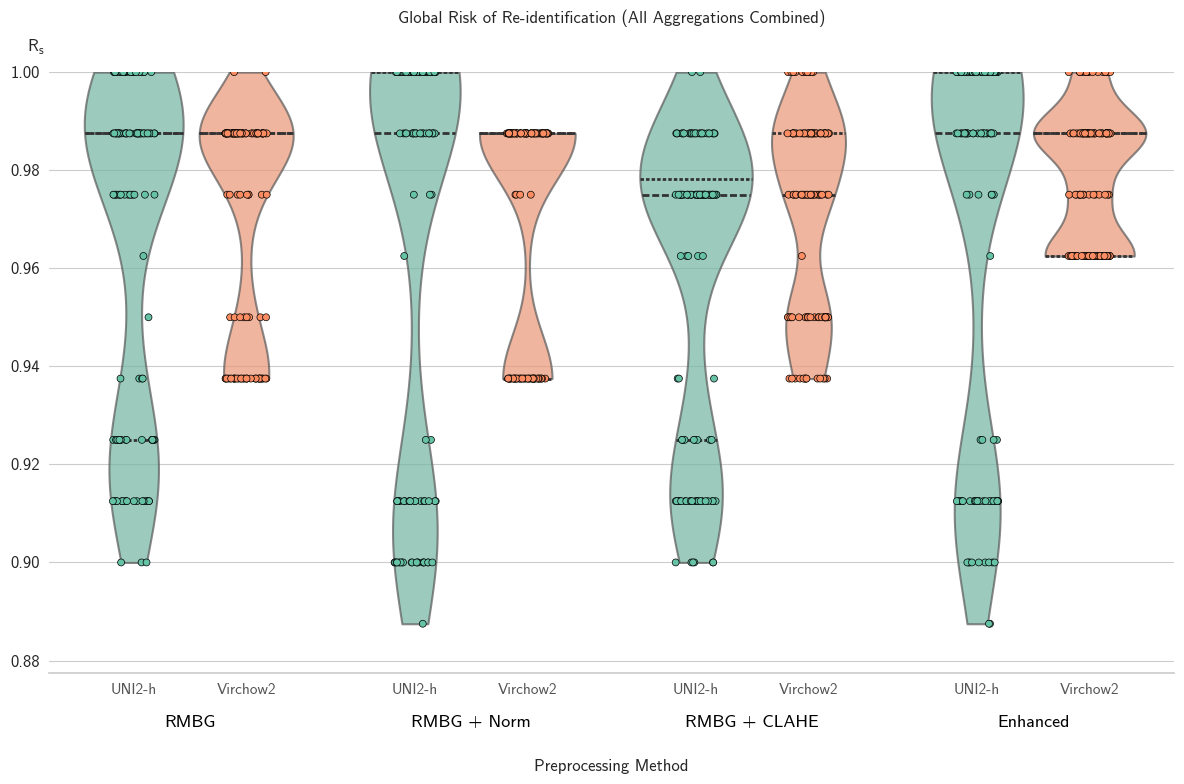

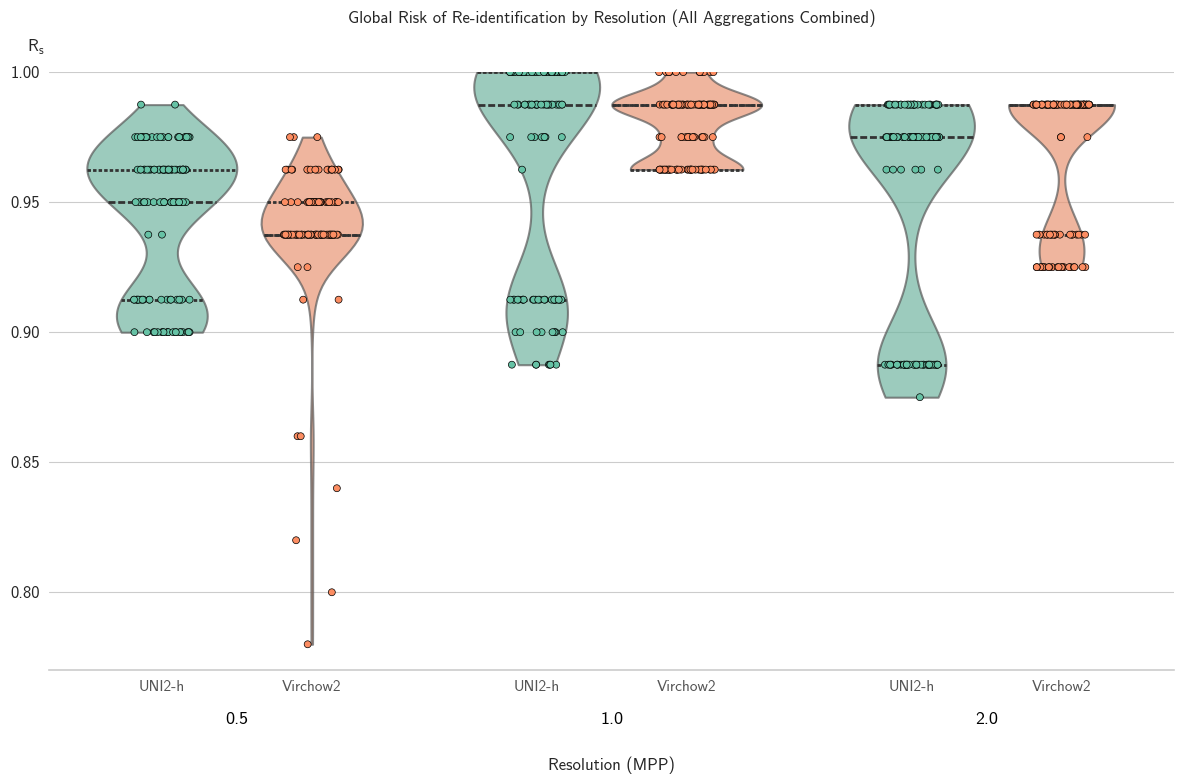

In [59]:
def plot_global_impact(df, experiment_type="preprocessing", output_dir="./data"):
    """
    Universal function for plotting hierarchical violin+strip plots.
    
    Args:
        df (pd.DataFrame): DataFrame with results.
        experiment_type (str): Either "preprocessing" or "mpp".
        output_dir (str): Directory to save the output plot.
    """
    os.makedirs(output_dir, exist_ok=True)
    df_plot = df.copy()

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Computer Modern Sans Serif", "cmss10", "Helvetica", "Arial"],
        "mathtext.fontset": "stixsans",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    _, ax = plt.subplots(figsize=(12, 8))
    encoder_order = sorted(df_plot["encoder"].unique())

    if experiment_type == "preprocessing":
        x_column = "preprocessing"
        x_label = "Preprocessing Method"
        title = "Global Risk of Re-identification (All Aggregations Combined)"
        file_name = "preprocessing_graph.png"
        
        mapping = {
            "rmbg": "RMBG",
            "rmbg_norm": "RMBG + Norm",
            "rmbg_clahe": "RMBG + CLAHE",
            "enhanced": "Enhanced"
        }
        categories_order = [cat for cat in mapping.keys() if cat in df_plot[x_column].unique()]
        if not categories_order:
            categories_order = sorted(df_plot[x_column].unique())

    elif experiment_type == "mpp":
        x_column = "mpp"
        x_label = "Resolution (MPP)"
        title = "Global Risk of Re-identification by Resolution (All Aggregations Combined)"
        file_name = "mpp_graph.png"
        
        df_plot[x_column] = df_plot[x_column].astype(str).str.replace(".0", "", regex=False).str.replace(".", "", regex=False)
        df_plot[x_column] = df_plot[x_column].replace({"5": "05"})
        
        categories_order = ["05", "10", "20"]
        mapping = {"05": "0.5", "10": "1.0", "20": "2.0"}

    sns.violinplot(
        data=df_plot,
        x=x_column,
        y="rs_value",
        hue="encoder",
        hue_order=encoder_order,
        order=categories_order,
        palette="Set2",       
        alpha=0.7,            
        linewidth=1.5,
        inner="quart",
        cut=0,                
        legend=False,
        ax=ax
    )

    for line in ax.lines:
        line.set_linewidth(2.0)
        line.set_color("#333333")

    sns.stripplot(
        data=df_plot,
        x=x_column,
        y="rs_value",
        hue="encoder",
        hue_order=encoder_order,
        order=categories_order,
        palette="Set2",       
        size=5,               
        alpha=1.0,            
        jitter=0.15,          
        dodge=True,           
        edgecolor="black",    
        linewidth=0.5,        
        legend=False,         
        ax=ax
    )

    sub_tick_positions = []
    sub_tick_labels = []
    for idx in range(len(categories_order)):
        sub_tick_positions.extend([idx - 0.2, idx + 0.2])
        sub_tick_labels.extend(encoder_order)

    ax.set_xticks(sub_tick_positions)
    ax.set_xticklabels(sub_tick_labels, color="#555555")

    for idx, cat_name in enumerate(categories_order):
        display_name = mapping.get(cat_name, cat_name)
        ax.text(
            x=idx,
            y=-0.07,
            s=display_name,
            transform=ax.get_xaxis_transform(),
            horizontalalignment="center",
            verticalalignment="top",
            fontsize=13,
            fontweight="bold",
            color="black"
        )

    ax.set_title(title, pad=35, fontweight="bold")
    ax.set_xlabel(x_label, labelpad=45)
    ax.set_ylabel("")

    ax.text(x=-0.01, y=1.03, s="R", transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom", fontsize=12, fontweight="bold")
    ax.text(x=-0.005, y=1.025, s="s", transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom", fontsize=9, fontweight="bold")

    plt.ylim(df_plot["rs_value"].min() - 0.01, 1.00)
    
    sns.despine(top=True, right=True, left=True, bottom=False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(1.2)
    
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_global_impact(df_preprocessing, experiment_type="preprocessing", output_dir=PLOT_PATH)
plot_global_impact(df_mpp, experiment_type="mpp", output_dir=PLOT_PATH)

# Synthetic data

In [60]:
import glob
from concurrent.futures import ThreadPoolExecutor

def _read_single_tile_parquet(f_orig):
    f_gen = f_orig.replace("orig_embeddings", "gen_embeddings")
    if not os.path.exists(f_gen): 
        return None
    
    p_id = os.path.basename(os.path.dirname(os.path.dirname(f_orig)))
    try:
        df_o = pd.read_parquet(f_orig, columns=['embedding'])
        df_g = pd.read_parquet(f_gen, columns=['embedding'])
        
        o_embs = np.vstack(df_o['embedding'].values).astype('float32')
        g_embs = np.vstack(df_g['embedding'].values).astype('float32')
        
        faiss.normalize_L2(o_embs)
        faiss.normalize_L2(g_embs)
        
        return p_id, {'orig': o_embs, 'gen': g_embs}
    except: 
        return None

def _load_tiles_data_parallel(root_path, encoder, variant):
    search_pattern = f"**/orig_embeddings_{encoder}_{variant}.parquet"
    orig_files = glob.glob(os.path.join(root_path, search_pattern), recursive=True)
    
    patient_data = {}
    with ThreadPoolExecutor(max_workers=8) as executor:
        results = list(tqdm(executor.map(_read_single_tile_parquet, orig_files), 
                           total=len(orig_files), desc=f"Loading {encoder}-{variant}"))
        
    for res in results:
        if res:
            p_id, data = res
            patient_data[p_id] = data
    return patient_data

def _evaluate_attack_core(orig_embs, gen_embs, gen_pids, orig_pids):
    dim = orig_embs.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(orig_embs)
    
    _, indices = index.search(gen_embs, min(5, len(orig_embs)))
    pred_pids = orig_pids[indices]
    
    t1_hits = np.sum(pred_pids[:, 0] == gen_pids)
    t5_hits = np.sum(np.any(pred_pids == gen_pids[:, None], axis=1))
    
    n = len(gen_embs)
    return (t1_hits / n) * 100, (t5_hits / n) * 100

def run_scaling_analysis(root_path, output_dir, encoders, variants, patient_counts, tile_counts, force_rerun=False):
    """Run scaling analysis on synthetic data."""
    out_path = Path(output_dir)
    out_path.mkdir(exist_ok=True, parents=True)
    
    csv_patients = out_path / "scaling_patients_all.csv"
    csv_tiles = out_path / "scaling_tiles_all.csv"
    
    if csv_patients.exists() and csv_tiles.exists() and not force_rerun:
        print(f"Found cached results in {output_dir}. Loading CSV files...")
        df_p = pd.read_csv(csv_patients)
        df_t = pd.read_csv(csv_tiles)
        return df_p, df_t

    all_scaling_p, all_scaling_t = [], []
    faiss.omp_set_num_threads(8)

    for enc in encoders:
        for var in variants:
            data = _load_tiles_data_parallel(root_path, enc, var)
            pids = sorted(list(data.keys()))
            if not pids: 
                continue
            
            all_o_list = [data[p]['orig'] for p in pids]
            all_g_list = [data[p]['gen'] for p in pids]
            
            o_pids_numeric = np.concatenate([np.full(len(all_o_list[idx]), idx) for idx in range(len(pids))])
            g_pids_numeric = np.concatenate([np.full(len(all_g_list[idx]), idx) for idx in range(len(pids))])

            for n in tqdm(patient_counts, desc="Scaling Patients"):
                if n > len(pids): 
                    continue
                
                mask_o = o_pids_numeric < n
                mask_g = g_pids_numeric < n
                
                curr_orig = np.concatenate(all_o_list[:n])
                curr_gen = np.concatenate(all_g_list[:n])
                
                t1, t5 = _evaluate_attack_core(curr_orig, curr_gen, g_pids_numeric[mask_g], o_pids_numeric[mask_o])
                all_scaling_p.append({"Encoder": enc, "Var": var, "N_Patients": n, "Top1": t1, "Top5": t5})

            for t in tqdm(tile_counts, desc="Scaling Tiles"):
                curr_orig = np.concatenate([emb[:t] for emb in all_o_list])
                curr_gen = np.concatenate(all_g_list)
                
                o_pids_t = np.concatenate([np.full(min(t, len(all_o_list[idx])), idx) for idx in range(len(pids))])
                
                t1, t5 = _evaluate_attack_core(curr_orig, curr_gen, g_pids_numeric, o_pids_t)
                all_scaling_t.append({"Encoder": enc, "Var": var, "N_Tiles": t, "Top1": t1, "Top5": t5})
                
            del data, all_o_list, all_g_list, o_pids_numeric, g_pids_numeric
            gc.collect()

    df_patients_final = pd.DataFrame(all_scaling_p)
    df_tiles_final = pd.DataFrame(all_scaling_t)
    
    df_patients_final.to_csv(csv_patients, index=False)
    df_tiles_final.to_csv(csv_tiles, index=False)
    
    return df_patients_final, df_tiles_final

In [61]:
ENCODERS = ["gigapath", "virchow2", "uni2h", "midnight12k", "simclrv2"]
VARIANTS = ["raw", "norm"]
PATIENT_COUNTS = [5, 10, 20, 40, 60, 80]
TILE_COUNTS = [1, 5, 10, 50, 100, 250, 500]

df_scaling_p, df_scaling_t = run_scaling_analysis(
    root_path=PARQUET_SYNTHETIC_TILES_PATH,
    output_dir=CSV_PATH,
    encoders=ENCODERS,
    variants=VARIANTS,
    patient_counts=PATIENT_COUNTS,
    tile_counts=TILE_COUNTS,
    force_rerun=False
)

print("\n--- SAMPLE PATIENTS ---")
print(df_scaling_p.head())

print("\n--- SAMPLE TILES ---")
print(df_scaling_t.head())

Loading gigapath-raw:   0%|          | 0/80 [00:00<?, ?it/s]

Scaling Tiles: 100%|██████████| 7/7 [07:16<00:00, 62.32s/it] 


--- SAMPLE PATIENTS ---
    Encoder  Var  N_Patients   Top1   Top5
0  gigapath  raw           5  40.80  78.12
1  gigapath  raw          10  21.70  56.64
2  gigapath  raw          20  13.85  39.45
3  gigapath  raw          40   8.99  27.19
4  gigapath  raw          60   8.13  22.85

--- SAMPLE TILES ---
    Encoder  Var  N_Tiles    Top1    Top5
0  gigapath  raw        1  3.8950  13.195
1  gigapath  raw        5  4.4250  15.345
2  gigapath  raw       10  4.5325  15.365
3  gigapath  raw       50  6.0675  18.460
4  gigapath  raw      100  6.3850  19.360


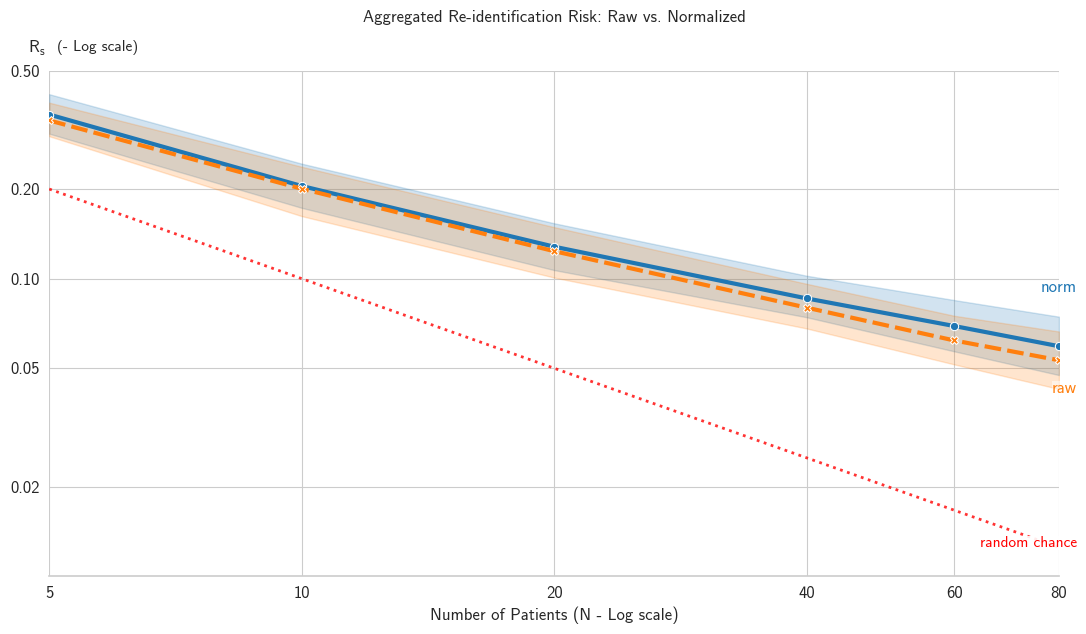

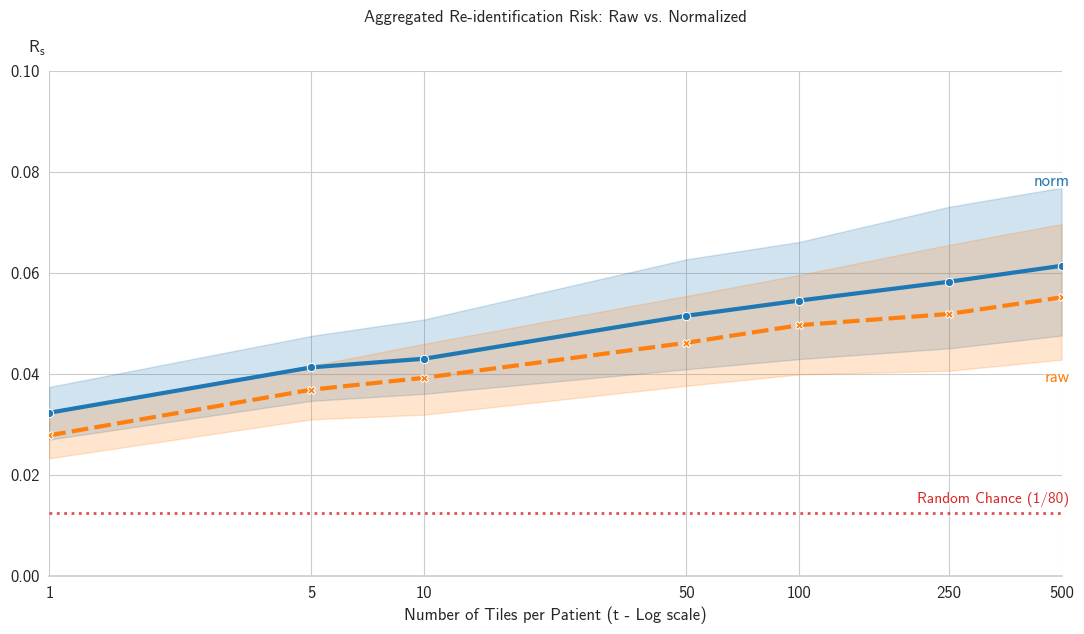

In [62]:
from matplotlib.ticker import NullFormatter, ScalarFormatter

def plot_scaling_results(csv_path, experiment_type, output_dir):
    """Plot scaling analysis results."""
        
    df_p = pd.read_csv(csv_path).copy()
    os.makedirs(output_dir, exist_ok=True)

    if df_p["Top1"].max() > 1.0:
        df_p["Top1"] = df_p["Top1"] / 100

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Computer Modern Sans Serif", "cmss10", "Helvetica", "Arial"],
        "mathtext.fontset": "stixsans",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
    })

    fig, ax = plt.subplots(figsize=(11, 6.5))

    if experiment_type == "patients":
        x_col = "N_Patients"
        x_label = "Number of Patients (N - Log scale)"
        title = "Aggregated Re-identification Risk: Raw vs. Normalized"
        file_name = "synth-raw-norm.png"
        
        x_ticks = np.sort(df_p[x_col].unique())
        max_real_x = df_p[x_col].max()
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        
        ax.set_yticks([0.02, 0.05, 0.1, 0.2, 0.5])
        plt.ylim(0.01, 0.5)
        
    elif experiment_type == "tiles":
        x_col = "N_Tiles"
        x_label = "Number of Tiles per Patient (t - Log scale)"
        title = "Aggregated Re-identification Risk: Raw vs. Normalized"
        file_name = "synt_tiles.png"
        
        x_ticks = np.sort(df_p[x_col].unique())
        max_real_x = df_p[x_col].max()
        
        ax.set_xscale("log")
        
        max_y_limit = 0.10  
        ax.set_yticks(np.arange(0.0, max_y_limit + 0.01, 0.02))
        plt.ylim(0.0, max_y_limit)

    sns.lineplot(
        data=df_p,
        x=x_col,
        y="Top1",
        hue="Var",
        style="Var",
        markers=True,
        linewidth=3,
        errorbar=("ci", 95),
        legend=False, 
        ax=ax,
    )

    ax.set_xticks(x_ticks)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.get_xaxis().set_minor_formatter(NullFormatter())
    ax.get_yaxis().set_major_formatter(ScalarFormatter())
    ax.get_yaxis().set_minor_formatter(NullFormatter())

    if experiment_type == "patients":
        ax.plot(x_ticks, 1 / x_ticks, color="red", linestyle=":", linewidth=2, alpha=0.8)
    else:
        ax.axhline(y=1/80, color="#d62728", linestyle=":", linewidth=2, alpha=0.8)

    ax.set_title(title, pad=35, fontweight="bold")
    ax.set_xlabel(x_label)
    ax.set_ylabel("") 

    ax.text(x=-0.01, y=1.03, s="R", transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom", fontsize=12, fontweight="bold")
    ax.text(x=-0.005, y=1.025, s="s", transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom", fontsize=9, fontweight="bold")
    
    if experiment_type == "patients":
        ax.text(x=0.008, y=1.03, s="(- Log scale)", transform=ax.transAxes, horizontalalignment="left", verticalalignment="bottom", fontsize=11)

    y_raw = df_p[(df_p["Var"] == "raw") & (df_p[x_col] == max_real_x)]["Top1"].mean()
    y_norm = df_p[(df_p["Var"] == "norm") & (df_p[x_col] == max_real_x)]["Top1"].mean()

    lines = [l for l in ax.get_lines() if l.get_color() not in ["red", "#d62728"]]
    color_norm, color_raw = "#4c72b0", "#dd8452"
    if len(lines) >= 2:
        color_norm = lines[0].get_color()
        color_raw = lines[1].get_color()

    if experiment_type == "patients":
        text_x_pos = max_real_x * 1.05 
        y_pos_raw = y_raw - 0.02
        y_pos_norm = y_norm + 0.035
        y_random = 1 / max_real_x
        s_random = "random chance"
        color_random = "red"
        y_pos_random = y_random
    else:
        text_x_pos = max_real_x * 1.05 
        y_pos_raw = y_raw - 0.023
        y_pos_norm = y_norm + 0.022
        y_random = 1 / 80
        s_random = "Random Chance (1/80)"
        color_random = "#d62728"
        y_pos_random = y_random + 0.002

    ax.text(
        x=text_x_pos, y=y_pos_raw, s="raw",
        horizontalalignment="right", fontsize=12, fontweight="bold", color=color_raw,
        bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0), clip_on=False
    )

    ax.text(
        x=text_x_pos, y=y_pos_norm, s="norm",
        horizontalalignment="right", fontsize=12, fontweight="bold", color=color_norm,
        bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0), clip_on=False
    )

    ax.text(
        x=text_x_pos, y=y_pos_random, s=s_random,
        horizontalalignment="right", fontsize=11, color=color_random,
        bbox=dict(facecolor="white", alpha=0.9 if experiment_type == "patients" else 0.5, edgecolor="none", pad=0), clip_on=False
    )

    ax.set_xlim(df_p[x_col].min(), max_real_x)
    sns.despine(top=True, right=True, left=True, bottom=False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(1.2)

    plt.tight_layout()
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_scaling_results(
    csv_path=CSV_PATH + "/scaling_patients_all.csv", 
    experiment_type="patients", 
    output_dir= PLOT_PATH
)

plot_scaling_results(
    csv_path=CSV_PATH + "/scaling_tiles_all.csv", 
    experiment_type="tiles", 
    output_dir= PLOT_PATH
)

# Different scanners

In [63]:
def load_cross_scanner_data(parquet_path, embedding_col="vlad_raw"):
    """
    Load and parse cross-scanner data with unified parsing logic.
    This is now consistent with load_slide_embeddings but returns scanner info.
    """
    table = pq.read_table(parquet_path, columns=[embedding_col, "__filename"])
    
    clean_embeddings = []
    clean_patient_ids = []
    clean_section_nums = []
    clean_scanners = []
    
    filenames = table.column("__filename").to_pylist()
    embeddings_list = table.column(embedding_col).to_pylist()

    for i in range(len(filenames)):
        decoded_path = urllib.parse.unquote(filenames[i])
        filename = decoded_path.split('/')[-1].upper()
        
        # Filter bad markers
        bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
        if any(m in filename for m in bad_markers):
            continue
            
        # Extract scanner type and patient ID
        match = re.search(r'^([A-Z]+).*?(\d{4}_.*?)\.MRXS', filename)
        
        if match:
            raw_scanner = match.group(1)
            full_id_with_sections = match.group(2)
            
            clean_patient_id = full_id_with_sections.rsplit('-', 1)[0]

            scanner = "FLASH" if "FLASH" in raw_scanner else "MIDI"
            
            section_match = re.search(r'-(\d{1,2})', full_id_with_sections)
            if section_match:
                section_num = int(section_match.group(1))
                if section_num > 13: continue
            else:
                continue

            clean_embeddings.append(embeddings_list[i])
            clean_patient_ids.append(clean_patient_id) 
            clean_section_nums.append(section_num)
            clean_scanners.append(scanner)

    embeddings = np.array(clean_embeddings, dtype='float32')
    patient_ids = np.array(clean_patient_ids)
    section_nums = np.array(clean_section_nums)
    scanners = np.array(clean_scanners)
    
    if len(embeddings) > 0:
        faiss.normalize_L2(embeddings)
    
    return patient_ids, section_nums, scanners, embeddings

In [ ]:
def calculate_rs_cross_scanner(patient_ids, scanners, embeddings):
    """Calculate cross-scanner re-identification risk."""
    unique_scanners = np.unique(scanners)
    if len(unique_scanners) < 2:
        print("Error: Not enough scanner types found for cross-scanner evaluation.")
        return 0.0

    mask_a = (scanners == unique_scanners[0])
    mask_b = (scanners == unique_scanners[1])

    ids_a, embs_a = patient_ids[mask_a], embeddings[mask_a]
    ids_b, embs_b = patient_ids[mask_b], embeddings[mask_b]

    index_b = faiss.IndexFlatIP(embs_b.shape[1])
    index_b.add(embs_b)
    _, indices_in_b = index_b.search(embs_a, 1)
    
    index_a = faiss.IndexFlatIP(embs_a.shape[1])
    index_a.add(embs_a)
    _, indices_in_a = index_a.search(embs_b, 1)

    correct_a_to_b = (ids_a == ids_b[indices_in_b.flatten()])
    correct_b_to_a = (ids_b == ids_a[indices_in_a.flatten()])

    vulnerable_patients = set()
    
    for i in range(len(ids_a)):
        if correct_a_to_b[i]:
            vulnerable_patients.add(ids_a[i])
            
    for i in range(len(ids_b)):
        if correct_b_to_a[i]:
            vulnerable_patients.add(ids_b[i])

    all_patients = set(patient_ids)
    num_vulnerable = len(vulnerable_patients)
    total_patients = len(all_patients)
    rs = num_vulnerable / total_patients if total_patients > 0 else 0

    return rs

In [ ]:
def analyze_cross_scan(base_path, enc, types, emb_col, seeds):
    """Analyze cross-scanner re-identification risk."""
    results_data = []
    detail_records = []

    for e in enc:
        for t in types:
            if not os.path.exists(base_path):
                print(f"Base path not found: {base_path}")
                continue
                
            for seed in seeds:
                seed_folder = f"run_seed_{seed}"
                current_path = os.path.join(base_path, seed_folder)
                
                if not os.path.exists(current_path):
                    continue
                    
                for col in emb_col:
                    
                    try:
                        pids, s_nums, scns, embs = load_cross_scanner_data(current_path, col)
                        if seed == seeds[0]:
                            for i in range(len(pids)):
                                detail_records.append({
                                    "encoder": f"ENC_{e}",
                                    "tissue_type": t,
                                    "method": col,
                                    "seed_folder": seed_folder,
                                    "patient_id": pids[i],
                                    "scanner": scns[i],
                                    "section_num": s_nums[i]
                                })

                        rs_val = calculate_rs_cross_scanner(pids, scns, embs)
                        
                        results_data.append({
                            "enc": f"Encoder {e}",
                            "method": col,
                            "rs_value": rs_val,
                            "type": t,
                            "seed": seed
                        })

                        del embs
                        gc.collect()    
                        
                    except Exception as ex:
                        print(f"Error processing {current_path}, {col}: {ex}")

    df_results = pd.DataFrame(results_data)
    return df_results

In [ ]:
enc = ["0", "1", "2", "3", "4"]
emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
    "mean_default",
    "mean_default_super"
]
types = ["prostate", "breast", "colon"]
seeds = list(range(42, 62))


if os.path.exists(CSV_PATH + "/cross_scanner.csv"):
    df_results = pd.read_csv(CSV_PATH + "/cross_scanner.csv")
else:
    df_results = analyze_cross_scan(PARQUET_CROSS_SCAN_PATH, enc, types, emb_col, seeds)
    df_results.to_csv(CSV_PATH + "/cross_scanner.csv", index=False)

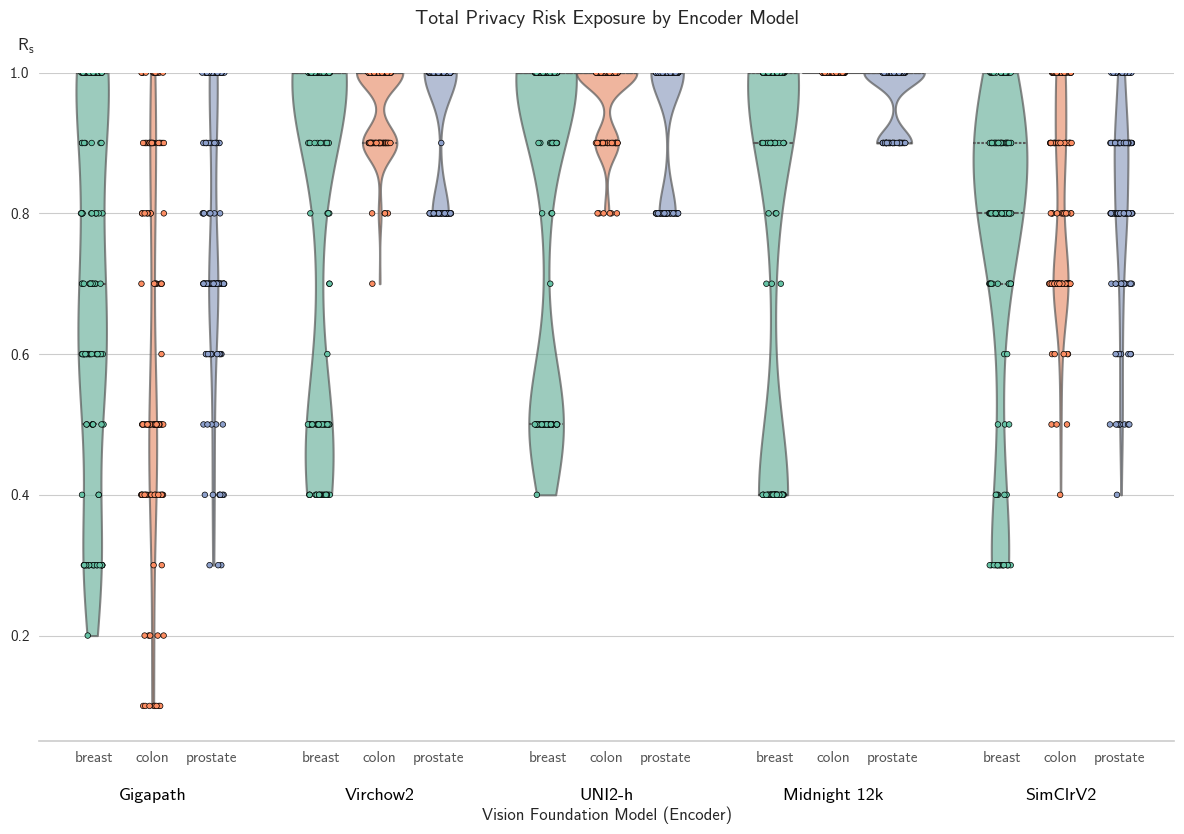

In [ ]:
if not df_results.empty:
    nice_encoder_names = {
        "Encoder 0": "Gigapath",
        "Encoder 1": "Virchow2",
        "Encoder 2": "UNI2-h",
        "Encoder 3": "Midnight 12k",
        "Encoder 4": "SimClrV2",
    }
    df_results["encoder_name"] = (
        df_results["enc"].map(nice_encoder_names).fillna(df_results["enc"])
    )

    sns.set_style("whitegrid")
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Computer Modern Sans Serif",
                "cmss10",
                "Helvetica",
                "Arial",
            ],
            "mathtext.fontset": "stixsans",
            "font.size": 12,
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

    plt.figure(figsize=(12, 8.5))

    encoder_order = [name for name in nice_encoder_names.values() if name in df_results["encoder_name"].unique()]
    if not encoder_order:
        encoder_order = sorted(df_results["encoder_name"].unique())

    ax = sns.violinplot(
        data=df_results,
        x="encoder_name",
        y="rs_value",
        hue="type",
        order=encoder_order,
        palette="Set2",       
        alpha=0.7,
        linewidth=1.5,
        inner="quart",        
        cut=0,
        legend=False,         
    )

    sns.stripplot(
        data=df_results,
        x="encoder_name",
        y="rs_value",
        hue="type",
        order=encoder_order,
        palette="Set2",
        size=4,
        alpha=1.0,            
        jitter=0.15,
        dodge=True,           
        edgecolor="black",
        linewidth=0.5,
        legend=False,
        ax=ax,
    )

    unique_tissues = sorted(df_results["type"].unique())

    ax.set_xticklabels([])

    offsets = [-0.26, 0.0, 0.26]
    
    sub_tick_positions = []
    for idx in range(len(encoder_order)):
        for off in offsets:
            sub_tick_positions.append(idx + off)
            
    sub_tick_labels = unique_tissues * len(encoder_order)

    ax.set_xticks(sub_tick_positions)
    ax.set_xticklabels(sub_tick_labels, color="#555555")

    for idx, enc_name in enumerate(encoder_order):
        ax.text(
            x=idx,
            y=-0.07,  
            s=enc_name,
            transform=ax.get_xaxis_transform(), 
            horizontalalignment="center",
            verticalalignment="top",
            fontsize=13,
            fontweight="bold",
            color="black"
        )

    plt.ylim(df_results["rs_value"].min() - 0.05, 1.00)
    ax.set_title("Total Privacy Risk Exposure by Encoder Model", pad=35, fontweight="bold")
    ax.set_xlabel("Vision Foundation Model (Encoder)", labelpad=30)
    ax.set_ylabel("")

    ax.text(
        x=-0.01, y=1.03, s="R",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=12, fontweight="bold",
    )
    ax.text(
        x=-0.005, y=1.025, s="s",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=9, fontweight="bold",
    )

    sns.despine(top=True, right=True, left=True, bottom=False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(1.2)

    plt.tight_layout()
    plt.show()

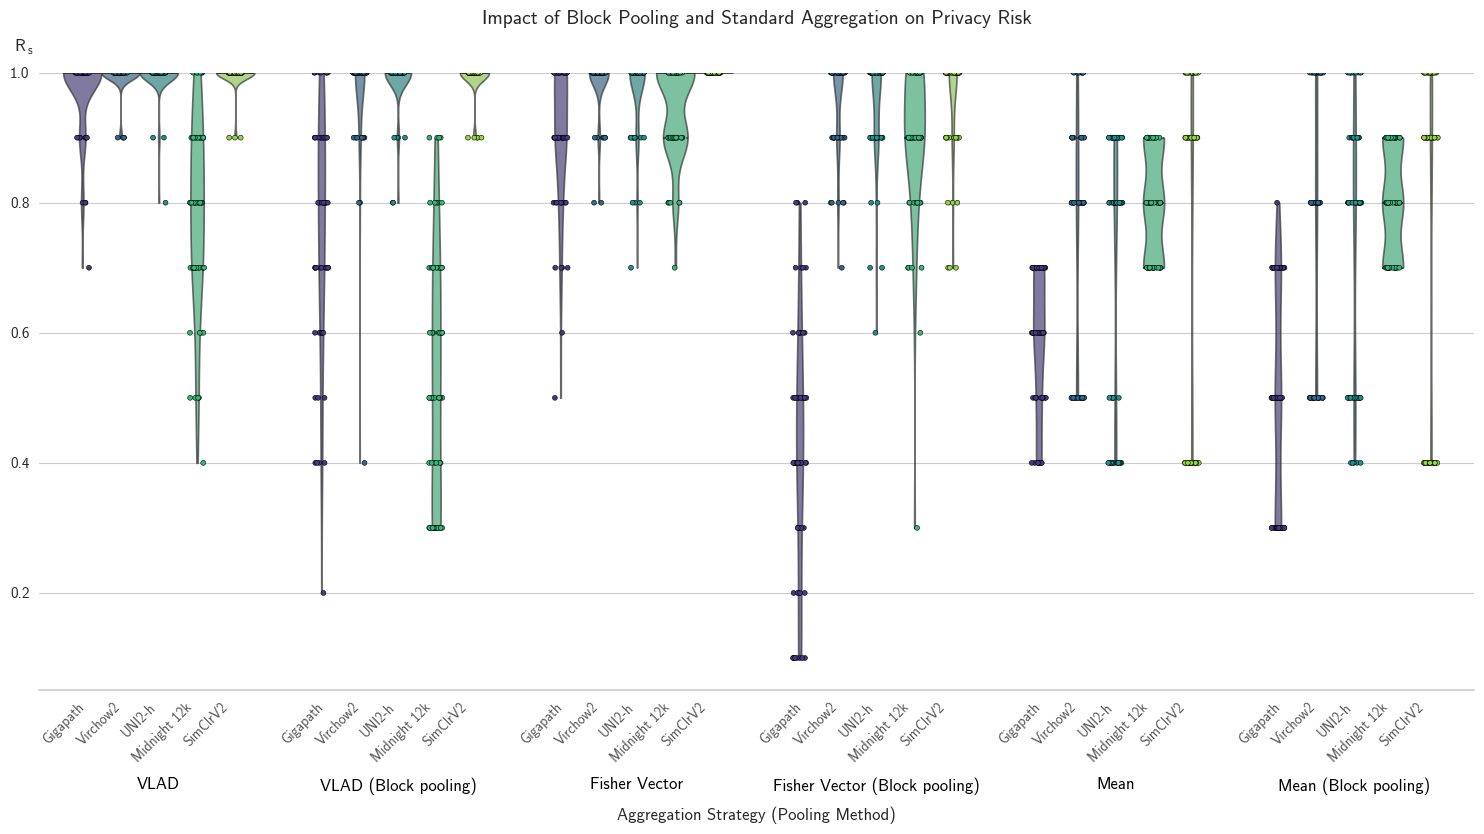

In [ ]:
if not df_results.empty:
    nice_method_names = {
        "vlad_default": "VLAD",
        "vlad_default_super": "VLAD (Block pooling)",
        "fisher_default": "Fisher Vector",
        "fisher_default_super": "Fisher Vector (Block pooling)",
        "mean_default": "Mean",
        "mean_default_super": "Mean (Block pooling)",
    }
    df_results["method_nice"] = (
        df_results["method"]
        .map(nice_method_names)
        .fillna(df_results["method"])
    )

    methods_order = [
        "VLAD",
        "VLAD (Block pooling)",
        "Fisher Vector",
        "Fisher Vector (Block pooling)",
        "Mean",
        "Mean (Block pooling)",
    ]
    df_results["method_nice"] = pd.Categorical(
        df_results["method_nice"], categories=methods_order, ordered=True
    )
    df_results = df_results.sort_values("method_nice")

    nice_encoder_names = ["Gigapath", "Virchow2", "UNI2-h", "Midnight 12k", "SimClrV2"]

    sns.set_style("whitegrid")
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Computer Modern Sans Serif",
                "cmss10",
                "Helvetica",
                "Arial",
            ],
            "mathtext.fontset": "stixsans",
            "font.size": 12,
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 11,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

    plt.figure(figsize=(15, 8.5))

    ax = sns.violinplot(
        data=df_results,
        x="method_nice",
        y="rs_value",
        hue="enc",
        order=methods_order,
        palette="viridis",
        alpha=0.7,
        linewidth=1.2,
        inner="quart",
        cut=0,
        legend=False,
    )

    sns.stripplot(
        data=df_results,
        x="method_nice",
        y="rs_value",
        hue="enc",
        order=methods_order,
        palette="viridis",
        size=3.5,
        alpha=1.0,            
        jitter=0.15,
        dodge=True,
        edgecolor="black",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    ax.set_xticklabels([])

    offsets = np.linspace(-0.3, 0.3, len(nice_encoder_names))
    
    sub_tick_positions = []
    for idx in range(len(methods_order)):
        for off in offsets:
            sub_tick_positions.append(idx + off)
            
    sub_tick_labels = nice_encoder_names * len(methods_order)

    ax.set_xticks(sub_tick_positions)
    ax.set_xticklabels(sub_tick_labels, color="#555555", rotation=45, horizontalalignment="right")

    for idx, method_name in enumerate(methods_order):
        ax.text(
            x=idx,
            y=-0.14,
            s=method_name,
            transform=ax.get_xaxis_transform(), 
            horizontalalignment="center",
            verticalalignment="top",
            fontsize=12,
            fontweight="bold",
            color="black"
        )

    plt.ylim(df_results["rs_value"].min() - 0.05, 1.00)
    ax.set_title("Impact of Block Pooling and Standard Aggregation on Privacy Risk", pad=35, fontweight="bold")
    ax.set_xlabel("Aggregation Strategy (Pooling Method)", labelpad=30)
    ax.set_ylabel("")

    ax.text(
        x=-0.01, y=1.03, s="R",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=12, fontweight="bold",
    )
    ax.text(
        x=-0.005, y=1.025, s="s",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=9, fontweight="bold",
    )

    sns.despine(top=True, right=True, left=True, bottom=False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(1.2)

    plt.tight_layout()
    plt.show()